<a href="https://colab.research.google.com/github/amitkumar-0509/sales-insights-python-project/blob/main/costomer_order_product_sales_data_analysis_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#|Q1| Which months had the highest and lowest revenue?
#|Q2| Which product categories are most profitavble?
#|Q3| Which customer segment spend the most?
#|Q4| Who are the top 10 customers by lifetime value?
#|Q5| Which city had the higest  revenue?


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
print(f"Numpy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Numpy version: 2.0.2
Pandas version: 2.2.2


#Upload The Data

In [8]:
orders= pd.read_csv("orders.csv")
products= pd.read_csv("products.csv")
customers= pd.read_csv("customers.csv")

In [10]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   order_id      1000 non-null   int64 
 1   customer_id   1000 non-null   int64 
 2   product_id    1000 non-null   int64 
 3   quantity      1000 non-null   int64 
 4   discount_pct  1000 non-null   int64 
 5   order_date    1000 non-null   object
dtypes: int64(5), object(1)
memory usage: 47.0+ KB


In [11]:
orders.describe()

,order_id,customer_id,product_id,quantity,discount_pct
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.0000
mean,1500.500000,225.830000,310.371000,3.049000,5.9000
std,288.819436,14.346809,5.780898,1.421485,5.8373
min,1001.000000,201.000000,301.000000,1.000000,0.0000
25%,1250.750000,214.000000,305.000000,2.000000,0.0000
50%,1500.500000,226.000000,310.000000,3.000000,5.0000
75%,1750.250000,237.000000,315.000000,4.000000,10.0000
max,2000.000000,250.000000,320.000000,5.000000,20.0000


In [12]:
quantities= orders["quantity"].values
prices= products["unit_price"].values
print(prices)

[4688.04 2390.79 4908.03 2731.12  880.43 3905.32 3505.87 3943.39 4773.21
 3959.68 3191.72 4335.49 3479.6  2246.75 4467.13 1380.84 3672.08 4448.27
 3749.62 3591.33]


In [15]:
print("Total units ordered: ", np.sum(quantities))
print("Average per ordered: ",np.mean(quantities).round(2))
print("Largest single order: ", np.max(quantities))
print("Smallest single order: ", np.min(quantities))
print("Cheapest product: ", np.min(prices))
print("Most expensive product: ", np.max(prices))
print("Average price: ", np.mean(prices).round(2))




Total units ordered:  3049
Average per ordered:  3.05
Largest single order:  5
Smallest single order:  1
Cheapest product:  880.43
Most expensive product:  4908.03
Average price:  3512.44


In [16]:
average_order_estimate= np.mean(prices)*np.mean(quantities)
print(average_order_estimate.round(2))

10709.42


#Adding sum null values because in real time you do not have clean data always


In [17]:
orders_dirty= orders.copy()
print(orders_dirty)

     order_id  customer_id  product_id  quantity  discount_pct  \
0        1001          239         301         5             0   
1        1002          229         306         5            20   
2        1003          215         306         1             0   
3        1004          243         316         2            10   
4        1005          208         304         4             0   
..        ...          ...         ...       ...           ...   
995      1996          226         301         5             5   
996      1997          234         301         1             0   
997      1998          245         319         4            15   
998      1999          206         316         3            10   
999      2000          237         314         1             5   

              order_date  
0     2024-01-01 0:00:00  
1     2024-01-01 8:00:00  
2    2024-01-01 16:00:00  
3     2024-01-02 0:00:00  
4     2024-01-02 8:00:00  
..                   ...  
995  2024-11-27 16

In [59]:
#Inject 50 null values on discount rows (50 rows)
blank_discount_rows= np.random.choice(orders_dirty.index, size= 50, replace=False)
orders_dirty.loc[blank_discount_rows, 'discount_pct'] = np.nan  #np.nan = blank

In [61]:
print(orders_dirty)

     order_id  customer_id  product_id  quantity  discount_pct  \
0        1001          239         301       5.0           0.0   
1        1002          229         306       5.0          20.0   
2        1003          215         306       1.0           NaN   
3        1004          243         316       2.0           NaN   
4        1005          208         304       4.0           0.0   
..        ...          ...         ...       ...           ...   
995      1996          226         301       5.0           5.0   
996      1997          234         301       1.0           0.0   
997      1998          245         319       4.0          15.0   
998      1999          206         316       3.0          10.0   
999      2000          237         314       1.0           5.0   

              order_date  discout_pct  
0     2024-01-01 0:00:00          NaN  
1     2024-01-01 8:00:00          NaN  
2    2024-01-01 16:00:00          NaN  
3     2024-01-02 0:00:00          NaN  
4     2

In [32]:
# Filter rows where "discount_pct" is NaN
nan_discount_rows = orders_dirty[orders_dirty["discout_pct"].isna()]

#Display the rows with NaN values in "discount_pct"

print("Rows with NaN values in 'discount_pct' column:")
display(nan_discount_rows)

Rows with NaN values in 'discount_pct' column:


,order_id,customer_id,product_id,quantity,discount_pct,order_date,discout_pct
0,1001,239,301,5.0,0.0,2024-01-01 0:00:00,NaN
1,1002,229,306,5.0,20.0,2024-01-01 8:00:00,NaN
2,1003,215,306,1.0,0.0,2024-01-01 16:00:00,NaN
3,1004,243,316,2.0,10.0,2024-01-02 0:00:00,NaN
4,1005,208,304,4.0,0.0,2024-01-02 8:00:00,NaN
...,...,...,...,...,...,...,...
995,1996,226,301,5.0,5.0,2024-11-27 16:00:00,NaN
996,1997,234,301,1.0,0.0,2024-11-28 0:00:00,NaN
997,1998,245,319,4.0,15.0,2024-11-28 8:00:00,NaN
998,1999,206,316,3.0,10.0,2024-11-28 16:00:00,NaN


In [33]:
#Inject 30 null values on quantiy (30 rows)
blank_quantity_rows= np.random.choice(orders_dirty.index, size= 30, replace= False)
orders_dirty.loc[blank_quantity_rows, "quantity"] = np.nan  #np.nan = blank

In [68]:
print(orders_dirty.isnull().sum())


order_id           0
customer_id        0
product_id         0
quantity          90
discount_pct     239
order_date         0
discout_pct     1000
dtype: int64


In [69]:
print(orders.isnull().sum())

order_id        0
customer_id     0
product_id      0
quantity        0
discount_pct    0
order_date      0
dtype: int64


In [58]:
print(orders_dirty.shape)

(1000, 7)


#Clean The Data


In [56]:
orders_clean= orders_dirty.drop_duplicates()
# Drop the 'discout_pct' column as it seems to be an erroneous column created by a typo.
orders_clean = orders_clean.drop(columns=['discout_pct'])

# Fill NaN values in 'discount_pct' with 0 (assuming no discount when value is missing).
orders_clean['discount_pct'] = orders_clean['discount_pct'].fillna(0)

# Fill NaN values in 'quantity' with the median quantity.
median_quantity = orders_clean['quantity'].median()
orders_clean['quantity'] = orders_clean['quantity'].fillna(median_quantity)


In [65]:
print(orders_clean.isnull().sum())

order_id        0
customer_id     0
product_id      0
quantity        0
discount_pct    0
order_date      0
dtype: int64


In [57]:
print(f"Shape of orders_clean DataFrame: {orders_clean.shape}")

Shape of orders_clean DataFrame: (1000, 6)


In [48]:
print(orders.shape)

(1000, 6)


#Conver Data Type

In [70]:
orders_clean["order_date"] = pd.to_datetime(orders_clean["order_date"])


In [71]:
customers["join_date"] = pd.to_datetime(customers["join_date"])


In [72]:
orders_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      1000 non-null   int64         
 1   customer_id   1000 non-null   int64         
 2   product_id    1000 non-null   int64         
 3   quantity      1000 non-null   float64       
 4   discount_pct  1000 non-null   float64       
 5   order_date    1000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(3)
memory usage: 47.0 KB


In [73]:
orders_clean['year'] = orders_clean['order_date'].dt.year
orders_clean['month'] = orders_clean['order_date'].dt.month
orders_clean['month_name'] = orders_clean['order_date'].dt.month_name()
orders_clean['day_name'] = orders_clean['order_date'].dt.day_name()
orders_clean['quarter'] = orders_clean['order_date'].dt.quarter

display(orders_clean.head())

,order_id,customer_id,product_id,quantity,discount_pct,order_date,year,month,month_name,day_name,quarter
0,1001,239,301,5.0,0.0,2024-01-01 00:00:00,2024,1,January,Monday,1
1,1002,229,306,5.0,20.0,2024-01-01 08:00:00,2024,1,January,Monday,1
2,1003,215,306,1.0,0.0,2024-01-01 16:00:00,2024,1,January,Monday,1
3,1004,243,316,2.0,0.0,2024-01-02 00:00:00,2024,1,January,Tuesday,1
4,1005,208,304,4.0,0.0,2024-01-02 08:00:00,2024,1,January,Tuesday,1


In [74]:
end_of_2024 = pd.to_datetime('2024-12-31')

#Data Analysis

In [75]:
customers["tenure_days"] = (end_of_2024 - customers["join_date"]).dt.days

In [76]:
customers[["customer_id", "join_date", "tenure_days"]].head()

,customer_id,join_date,tenure_days
0,201,2022-01-01,1095
1,202,2022-01-16,1080
2,203,2022-01-31,1065
3,204,2022-02-15,1050
4,205,2022-03-02,1035


In [80]:
def assign_age_group(age):
  if age < 25: return "18-24"
  elif age < 35: return "25-34"
  elif age < 45: return "35-44"
  elif age < 55: return "45+"

customers["age_group"] = customers["age"].apply(assign_age_group)

print("customers age per group:")
print(customers["age_group"].value_counts())

customers age per group:
age_group
45+      18
25-34    15
35-44     6
18-24     5
Name: count, dtype: int64


In [81]:
master = pd.merge(orders_clean, products, on='product_id', how='inner')
print(f"Shape of master DataFrame: {master.shape}")

Shape of master DataFrame: (1000, 15)


In [83]:
master = pd.merge(master, customers, on='customer_id', how='inner')
print(f"Shape of master DataFrame after merging with customers: {master.shape}")

Shape of master DataFrame after merging with customers: (1000, 21)


In [84]:
master["gross_revenue"]   = master["quantity"] * master["unit_price"]
master["discount_amount"] = master["gross_revenue"] *( master["discount_pct"] / 100)
master["net_revenue"]     = master["gross_revenue"] - master["discount_amount"]
master["cost"]            = master["quantity"] * master["unit_cost"]
master["profit"]          = master["net_revenue"] - master["cost"]
master["profit_margin"]   =np.round((master["profit"] / master["net_revenue"]) * 100, 2)

In [86]:
master[["order_id", "quantity", "unit_price", "discount_pct",
       "gross_revenue", "net_revenue", "profit", "profit_margin"]].head(5)

,order_id,quantity,unit_price,discount_pct,gross_revenue,net_revenue,profit,profit_margin
0,1001,5.0,4688.04,0.0,23440.20,23440.20,9163.95,39.10
1,1002,5.0,3905.32,20.0,19526.60,15621.28,6631.58,42.45
2,1003,1.0,3905.32,0.0,3905.32,3905.32,2107.38,53.96
3,1004,2.0,1380.84,0.0,2761.68,2761.68,18.42,0.67
4,1005,4.0,2731.12,0.0,10924.48,10924.48,-1668.72,-15.28


In [88]:
print("=" * 55)
print("  SHOPEASE INDIA - 2024 ANNUAL REPORT  ")
print("=" * 55)
print(f"   Total Orders        : {master['order_id'].nunique()}")
print(f"   Total Customers     : {master['customer_id'].nunique()}")
print(f"   Gross Revenue       : RS.{master['gross_revenue'].sum():,.0f}")
print(f"   Total Discounts     : RS.{master['discount_amount'].sum():,.0f}")
print(f"   Net Revenue         : RS.{master['net_revenue'].sum():,.0f}")
print(f"   Total Profit        : RS.{master['profit'].sum():,.0f}")
print(f"   Average Order Value : RS.{master['net_revenue'].mean():,.0f}")
print(f"   Average profit Margin: {master['profit_margin'].mean():,.1f}%")
print("=" * 55)


  SHOPEASE INDIA - 2024 ANNUAL REPORT  
   Total Orders        : 1000
   Total Customers     : 50
   Gross Revenue       : RS.10,879,711
   Total Discounts     : RS.523,209
   Net Revenue         : RS.10,356,503
   Total Profit        : RS.4,428,620
   Average Order Value : RS.10,357
   Average profit Margin: 31.6%


In [90]:
monthly_revenue = master.groupby('month_name')['net_revenue'].sum().sort_values(ascending=False)

highest_revenue_month = monthly_revenue.index[0]
highest_revenue_amount = monthly_revenue.iloc[0]

lowest_revenue_month = monthly_revenue.index[-1]
lowest_revenue_amount = monthly_revenue.iloc[-1]


print(f"Month with the highest revenue: {highest_revenue_month} (RS.{monthly_revenue.iloc[0]:,.0f})")
print(f"Month with the lowest revenue: {lowest_revenue_month} (RS.{monthly_revenue.iloc[-1]:,.0f})")

Month with the highest revenue: May (RS.1,045,833)
Month with the lowest revenue: June (RS.840,686)


/tmp/ipykernel_1798/5365102.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_revenue.index, y=monthly_revenue.values, palette='viridis')


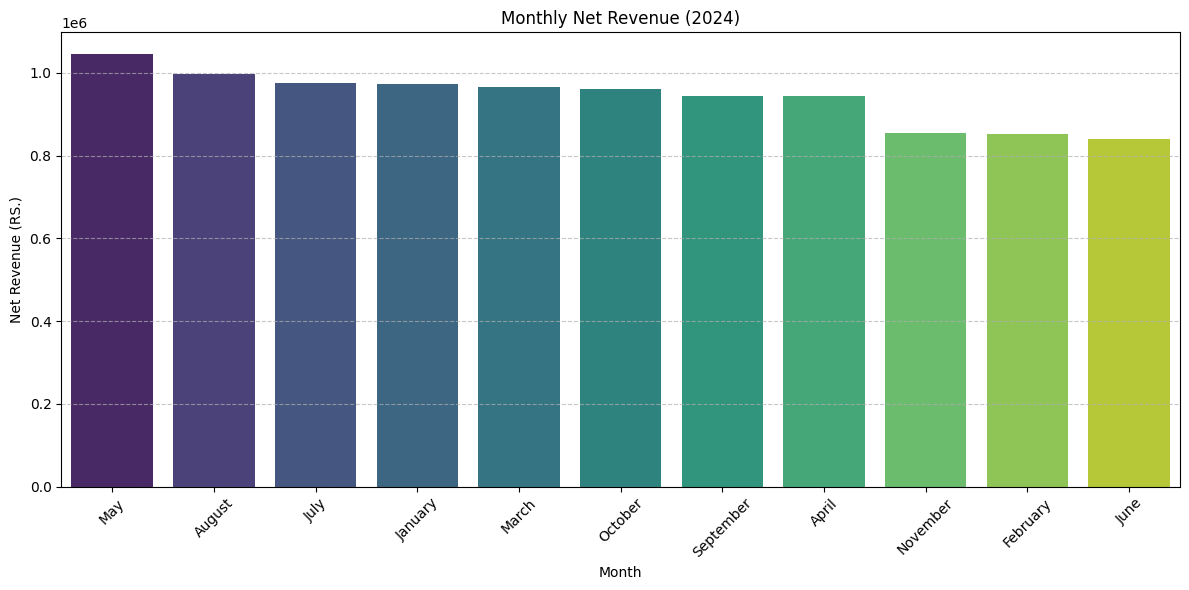

In [91]:
plt.figure(figsize=(12, 6))
sns.barplot(x=monthly_revenue.index, y=monthly_revenue.values, palette='viridis')
plt.title('Monthly Net Revenue (2024)')
plt.xlabel('Month')
plt.ylabel('Net Revenue (RS.)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [92]:
category_profit = master.groupby('category')['profit'].sum().sort_values(ascending=False)

print("Most profitable product categories:")
display(category_profit)

Most profitable product categories:


,profit
category,
Sports,1.486253e+06
Electronics,1.115458e+06
Fashion,1.042361e+06
Home & Kitchen,7.845482e+05


/tmp/ipykernel_1798/3419639164.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_profit.index, y=category_profit.values, palette='plasma')


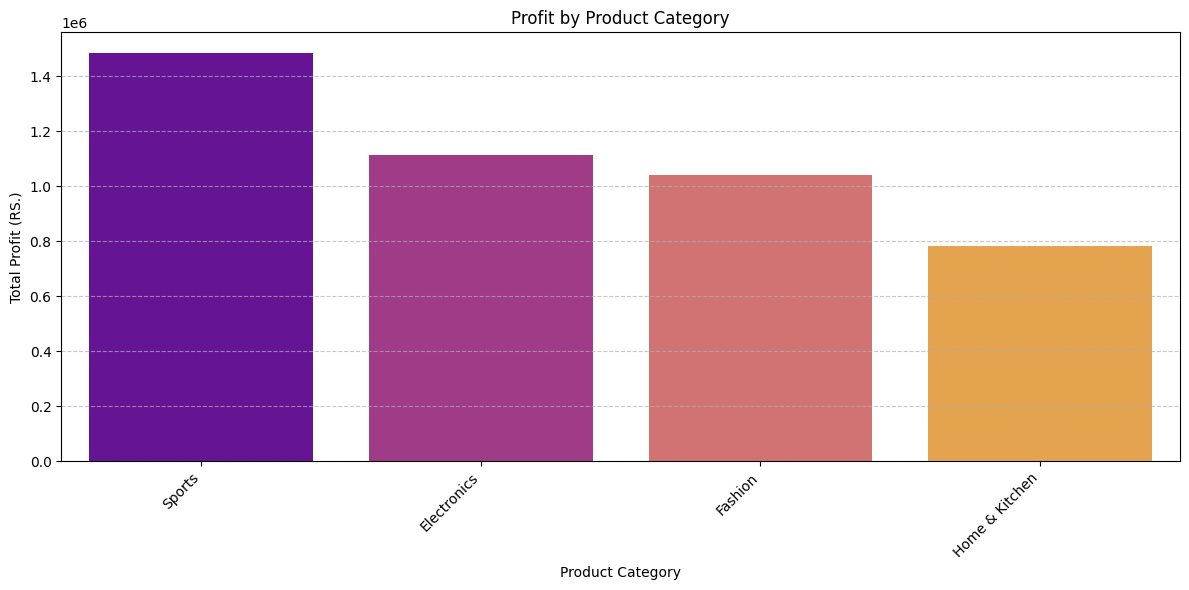

In [93]:
plt.figure(figsize=(12, 6))
sns.barplot(x=category_profit.index, y=category_profit.values, palette='plasma')
plt.title('Profit by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Profit (RS.)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [94]:
customer_segment_revenue = master.groupby('age_group')['net_revenue'].sum().sort_values(ascending=False)

print("Customer segments by total net revenue:")
display(customer_segment_revenue)

Customer segments by total net revenue:


,net_revenue
age_group,
45+,4.036788e+06
25-34,2.683538e+06
35-44,1.327811e+06
18-24,1.000052e+06


/tmp/ipykernel_1798/1670506016.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=customer_segment_revenue.index, y=customer_segment_revenue.values, palette='coolwarm')


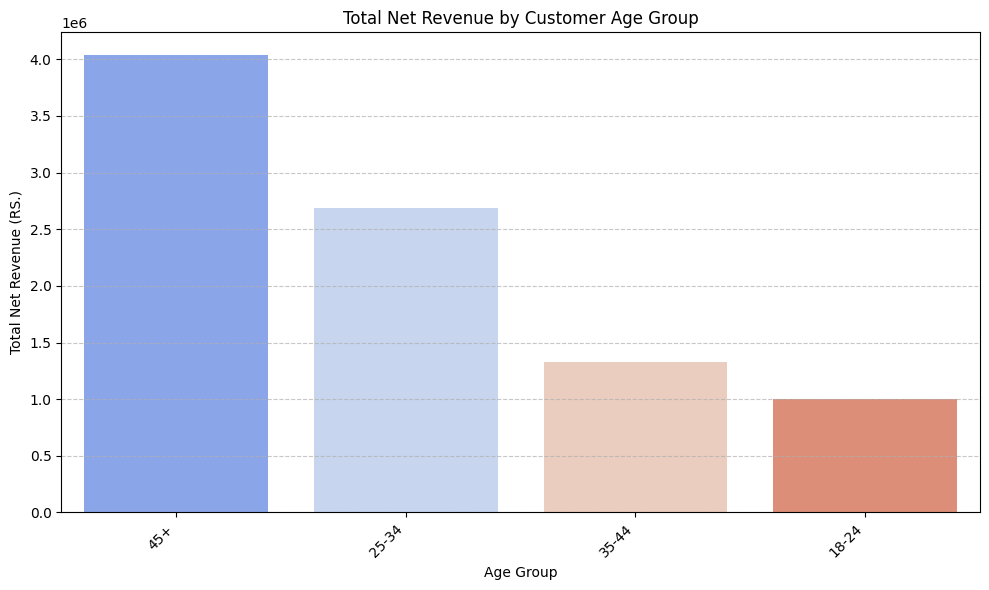

In [95]:
plt.figure(figsize=(10, 6))
sns.barplot(x=customer_segment_revenue.index, y=customer_segment_revenue.values, palette='coolwarm')
plt.title('Total Net Revenue by Customer Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Net Revenue (RS.)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [99]:
customer_lifetime_value = master.groupby('customer_id')['net_revenue'].sum().sort_values(ascending=False)

print("Top 10 Customers by Lifetime Value:")
display(customer_lifetime_value.head(10))

Top 10 Customers by Lifetime Value:


,net_revenue
customer_id,
233,330303.9400
226,295899.8120
247,290470.4495
249,290222.5640
208,289441.9765
232,283965.1865
239,268996.4390
217,259919.5000
202,253542.4500


In [100]:
city_revenue = master.groupby('city')['net_revenue'].sum().sort_values(ascending=False)

highest_revenue_city = city_revenue.index[0]
highest_revenue_amount = city_revenue.iloc[0]

print(f"City with the highest revenue: {highest_revenue_city} (RS.{highest_revenue_amount:,.0f})")
print("\nTotal Net Revenue by City:")
display(city_revenue)

City with the highest revenue: Bengaluru (RS.3,115,180)

Total Net Revenue by City:


,net_revenue
city,
Bengaluru,3.115180e+06
Pune,2.673113e+06
Chennai,2.031226e+06
Delhi,9.178101e+05
Mumbai,9.171271e+05
Hyderabad,7.020454e+05


/tmp/ipykernel_1798/3408388397.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_revenue.index, y=city_revenue.values, palette='crest')


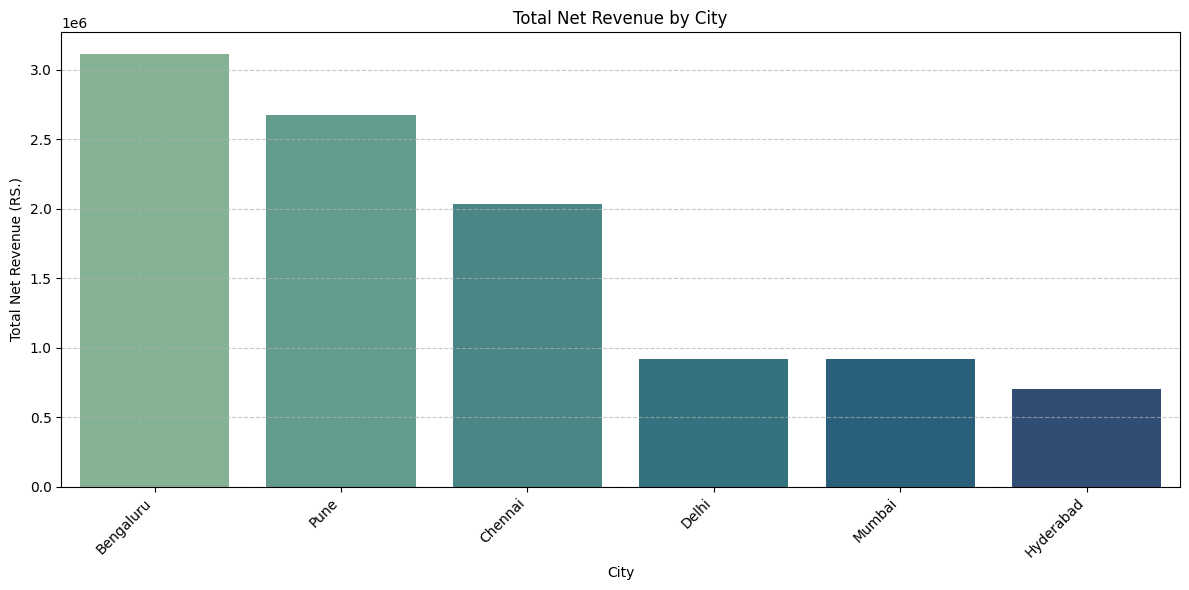

In [101]:
plt.figure(figsize=(12, 6))
sns.barplot(x=city_revenue.index, y=city_revenue.values, palette='crest')
plt.title('Total Net Revenue by City')
plt.xlabel('City')
plt.ylabel('Total Net Revenue (RS.)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [102]:
age_gender_revenue = master.groupby(['age_group', 'gender'])['net_revenue'].sum().sort_values(ascending=False)

print("Total Net Revenue by Age Group and Gender:")
display(age_gender_revenue)

Total Net Revenue by Age Group and Gender:


age_group  gender
45+        Female    2.226271e+06
           Male      1.810517e+06
25-34      Male      1.651309e+06
           Female    1.032228e+06
35-44      Female    8.320524e+05
18-24      Male      6.148283e+05
35-44      Male      4.957589e+05
18-24      Female    3.852234e+05
Name: net_revenue, dtype: float64

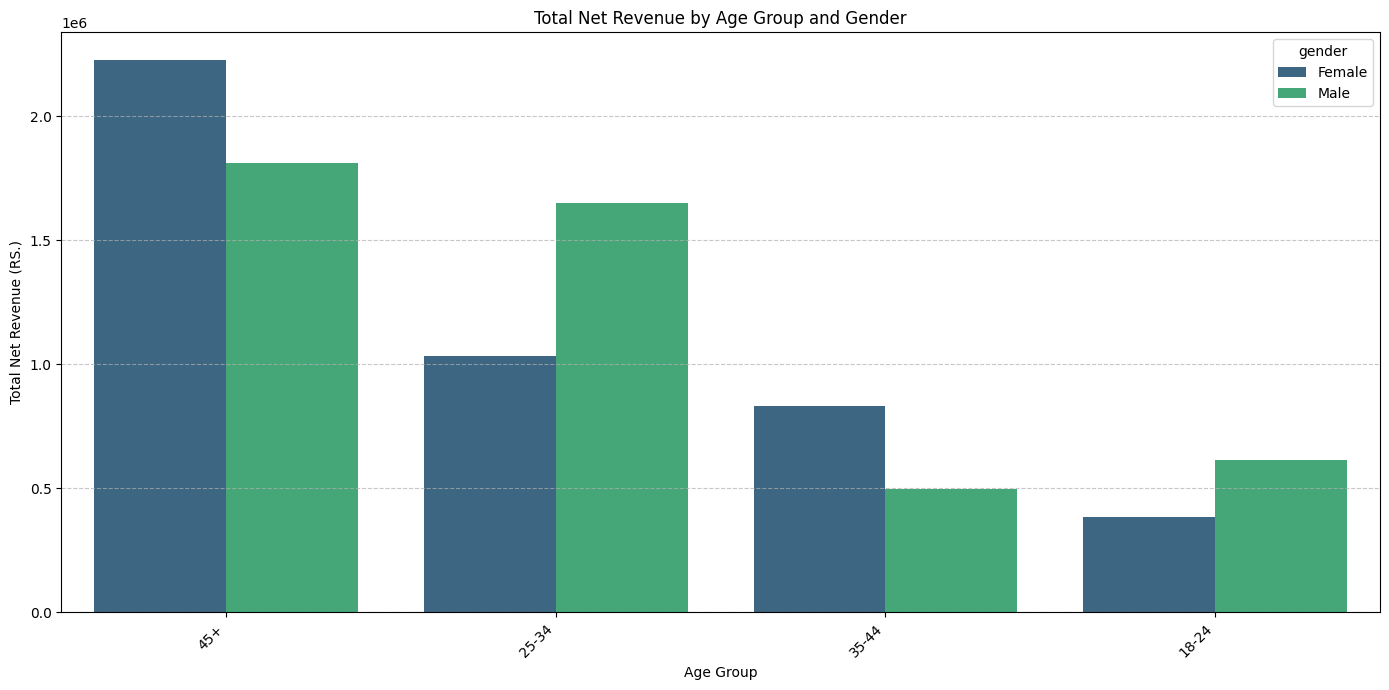

In [103]:
plt.figure(figsize=(14, 7))
sns.barplot(x='age_group', y='net_revenue', hue='gender', data=age_gender_revenue.reset_index(), palette='viridis')
plt.title('Total Net Revenue by Age Group and Gender')
plt.xlabel('Age Group')
plt.ylabel('Total Net Revenue (RS.)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [104]:
daily_revenue = master.groupby('day_name')['net_revenue'].sum().sort_values(ascending=False)

# Reorder days for better visualization (optional, but good practice)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_revenue = daily_revenue.reindex(day_order, fill_value=0).sort_values(ascending=False)

busiest_day = daily_revenue.index[0]
busiest_day_revenue = daily_revenue.iloc[0]

print(f"The busiest day of the week by net revenue is {busiest_day} (RS.{busiest_day_revenue:,.0f})")
print("\nTotal Net Revenue by Day of the Week:")
display(daily_revenue)

The busiest day of the week by net revenue is Friday (RS.1,551,269)

Total Net Revenue by Day of the Week:


,net_revenue
day_name,
Friday,1.551269e+06
Wednesday,1.545141e+06
Monday,1.519680e+06
Thursday,1.497651e+06
Sunday,1.449839e+06
Tuesday,1.417068e+06
Saturday,1.375856e+06


/tmp/ipykernel_1798/4260958547.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=daily_revenue.index, y=daily_revenue.values, palette='coolwarm')


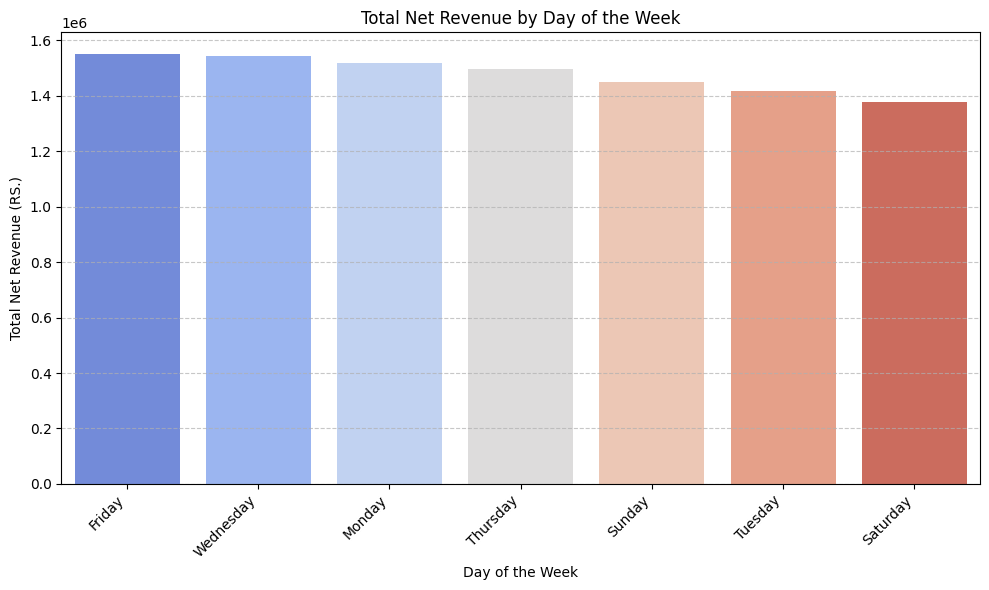

In [105]:
plt.figure(figsize=(10, 6))
sns.barplot(x=daily_revenue.index, y=daily_revenue.values, palette='coolwarm')
plt.title('Total Net Revenue by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Total Net Revenue (RS.)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [108]:
discount_impact = master.groupby('discount_pct')[['net_revenue', 'profit']].sum().sort_index()

print("Impact of Discount Percentage on Net Revenue and Profit:")
display(discount_impact)

Impact of Discount Percentage on Net Revenue and Profit:


,net_revenue,profit
discount_pct,,
0.0,5.374351e+06,2.439956e+06
5.0,2.220264e+06,9.373166e+05
10.0,1.591368e+06,6.161494e+05
15.0,8.581050e+05,2.957764e+05
20.0,3.124155e+05,1.394225e+05


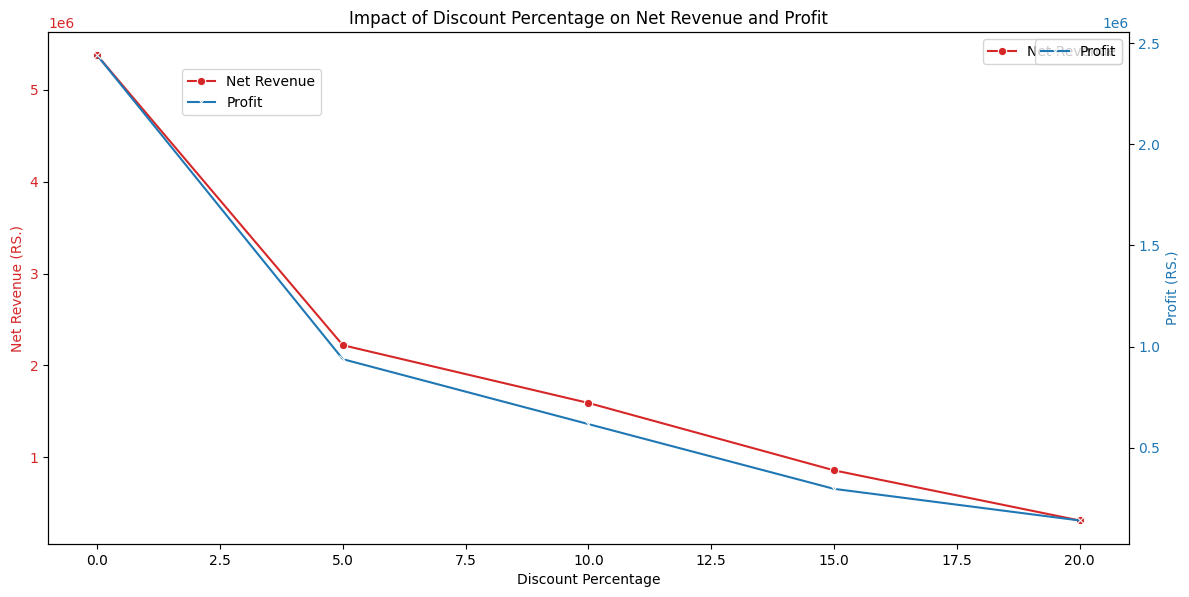

In [109]:
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:red'
ax1.set_xlabel('Discount Percentage')
ax1.set_ylabel('Net Revenue (RS.)', color=color)
sns.lineplot(x=discount_impact.index, y=discount_impact['net_revenue'], ax=ax1, color=color, marker='o', label='Net Revenue')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('Profit (RS.)', color=color)  # we already handled the x-label with ax1
sns.lineplot(x=discount_impact.index, y=discount_impact['profit'], ax=ax2, color=color, marker='x', label='Profit')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('Impact of Discount Percentage on Net Revenue and Profit')
fig.legend(loc='upper left', bbox_to_anchor=(0.15, 0.9))
plt.show()

In [110]:
quarterly_performance = master.groupby('quarter')[['net_revenue', 'profit']].sum().sort_index()

print("Quarterly Net Revenue and Profit:")
display(quarterly_performance)

Quarterly Net Revenue and Profit:


,net_revenue,profit
quarter,,
1,2.791552e+06,1.150745e+06
2,2.829570e+06,1.133153e+06
3,2.917970e+06,1.253959e+06
4,1.817410e+06,8.907641e+05


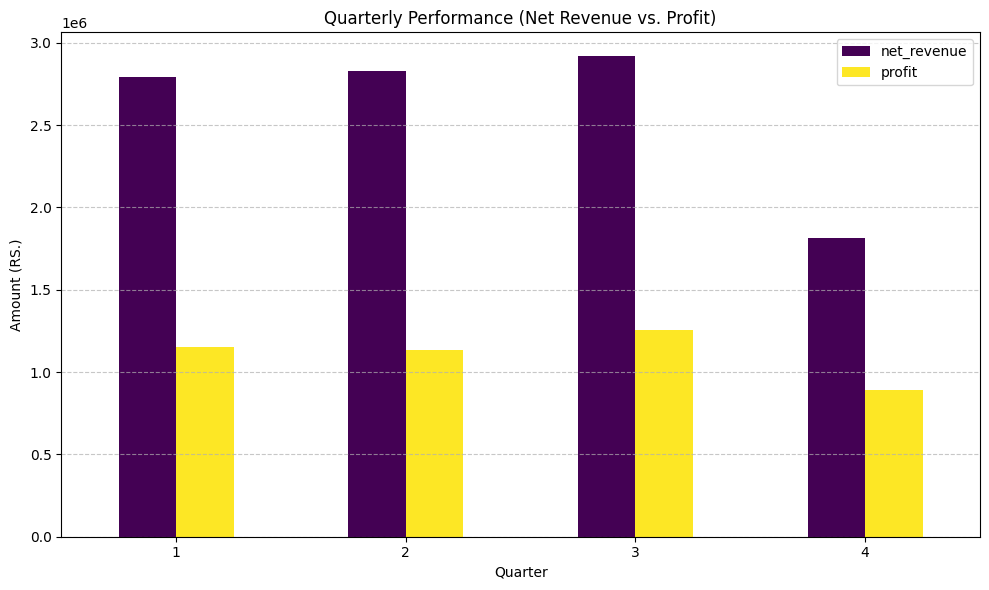

In [111]:
fig, ax = plt.subplots(figsize=(10, 6))

quarterly_performance[['net_revenue', 'profit']].plot(kind='bar', ax=ax, colormap='viridis')

plt.title('Quarterly Performance (Net Revenue vs. Profit)')
plt.xlabel('Quarter')
plt.ylabel('Amount (RS.)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [112]:
product_profitability = master.groupby('product_name')['profit'].sum().sort_values(ascending=False)

best_product = product_profitability.index[0]
best_product_profit = product_profitability.iloc[0]

worst_product = product_profitability.index[-1]
worst_product_profit = product_profitability.iloc[-1]

print(f"Best Performing Product: {best_product} (RS.{best_product_profit:,.0f})")
print(f"Worst Performing Product: {worst_product} (RS.{worst_product_profit:,.0f})")

print("\nProduct Profitability:")
display(product_profitability)

Best Performing Product: Product_318 (RS.660,518)
Worst Performing Product: Product_302 (RS.-121,945)

Product Profitability:


,profit
product_name,
Product_318,660517.6445
Product_312,614925.4660
Product_308,524761.7595
Product_310,451452.5940
Product_317,406502.2480
Product_315,382432.0005
Product_303,362526.9025
Product_319,324107.3210
Product_306,300437.7100


/tmp/ipykernel_1798/1971576647.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_profitability.index, y=product_profitability.values, palette='RdYlGn')


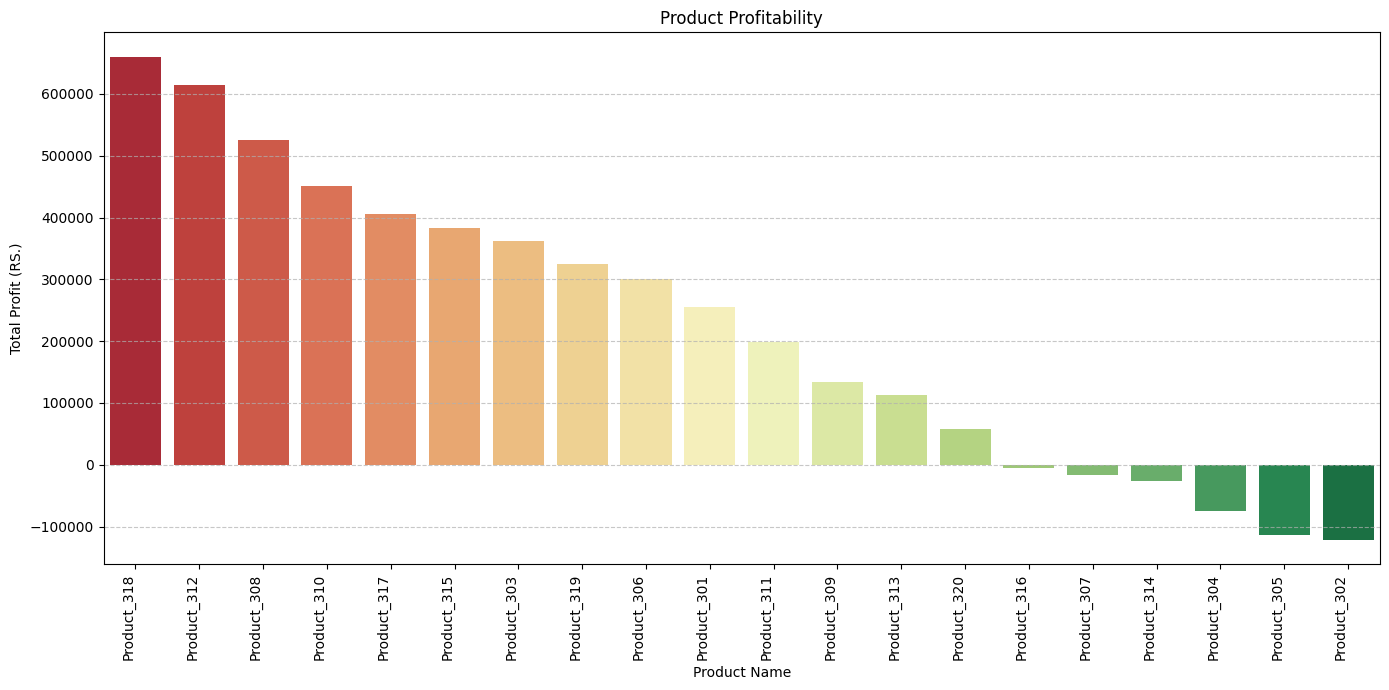

In [113]:
plt.figure(figsize=(14, 7))
sns.barplot(x=product_profitability.index, y=product_profitability.values, palette='RdYlGn')
plt.title('Product Profitability')
plt.xlabel('Product Name')
plt.ylabel('Total Profit (RS.)')
plt.xticks(rotation=90, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()